# CAPSTONE PROJECT 1
## Working with NumPy Matrices – NHANES Body Measurements

### Objective

This project analyzes body measurements of adult males and females
from the National Health and Nutrition Examination Survey (NHANES).

The analysis includes:

- Loading male and female datasets as NumPy matrices
- Weight distribution visualization
- Box-and-whisker plots
- Numerical statistical analysis
- Body Mass Index (BMI) calculation
- Z-score standardization
- Scatterplot matrix
- Pearson and Spearman correlation
- Waist-to-height ratio
- Waist-to-hip ratio
- Comparison of body-measurement ratios
- BMI-based analysis of extreme observations

## 1. Import Required Libraries

The following libraries are used for numerical calculations, data
visualization, statistical analysis, and scatterplot matrices.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from scipy.stats import skew, kurtosis, pearsonr, spearmanr

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Download the NHANES Datasets

The datasets contain seven body measurements for adult males and
females:

1. Weight (kg)
2. Standing height (cm)
3. Upper arm length (cm)
4. Upper leg length (cm)
5. Arm circumference (cm)
6. Hip circumference (cm)
7. Waist circumference (cm)

In [ ]:
male_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_male_bmx_2020.csv"
female_url = "https://raw.githubusercontent.com/gagolews/teaching-data/master/marek/nhanes_adult_female_bmx_2020.csv"

!wget -q "$male_url" -O male.csv
!wget -q "$female_url" -O female.csv

print("Datasets downloaded successfully.")

Datasets downloaded successfully.


## 3. Load the Datasets as NumPy Matrices

The CSV files are loaded into NumPy arrays. Since the source files
contain descriptive comment lines, they are skipped while reading.

In [ ]:
male = np.genfromtxt(
    "male.csv",
    delimiter=",",
    skip_header=1
)

female = np.genfromtxt(
    "female.csv",
    delimiter=",",
    skip_header=1
)

print("Male matrix shape:", male.shape)
print("Female matrix shape:", female.shape)

Male matrix shape: (4082, 7)
Female matrix shape: (4222, 7)


In [ ]:
print("First 5 rows of male matrix:")
print(male[:5])

print("\nFirst 5 rows of female matrix:")
print(female[:5])

First 5 rows of male matrix:
[[  nan   nan   nan   nan   nan   nan   nan]
 [ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]
 [ 86.  167.8  39.5  38.4  29.  106.4 108.3]]

First 5 rows of female matrix:
[[  nan   nan   nan   nan   nan   nan   nan]
 [ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]
 [ 61.7 157.4  38.   34.7  29.  101.   90.5]]


### Result

The datasets have been successfully loaded as NumPy matrices.

Each row represents one participant, while the seven columns represent
the body measurements specified in the project.

In [ ]:
column_names = [
    "Weight_kg",
    "Height_cm",
    "UpperArmLength_cm",
    "UpperLegLength_cm",
    "ArmCircumference_cm",
    "HipCircumference_cm",
    "WaistCircumference_cm"
]

print("Number of columns:", len(column_names))
print(column_names)

Number of columns: 7
['Weight_kg', 'Height_cm', 'UpperArmLength_cm', 'UpperLegLength_cm', 'ArmCircumference_cm', 'HipCircumference_cm', 'WaistCircumference_cm']


## 4. Extract Weight Measurements

Weight is the first column of both matrices. We extract the weight
vectors so that their distributions can be compared.

In [ ]:
female_weights = female[:, 0]
male_weights = male[:, 0]

print("Female weight sample:")
print(female_weights[:10])

print("\nMale weight sample:")
print(male_weights[:10])

Female weight sample:
[ nan 97.1 91.1 73.  61.7 55.4 62.  66.2 75.9 77.2]

Male weight sample:
[  nan  98.8  74.3 103.7  86.   99.4  90.2  45.5  64.   67.9]


## 5. Weight Distribution Histograms

Histograms are used to visualize the distribution of body weight.
The same x-axis limits are used for both groups to make the comparison
fair and visually meaningful.

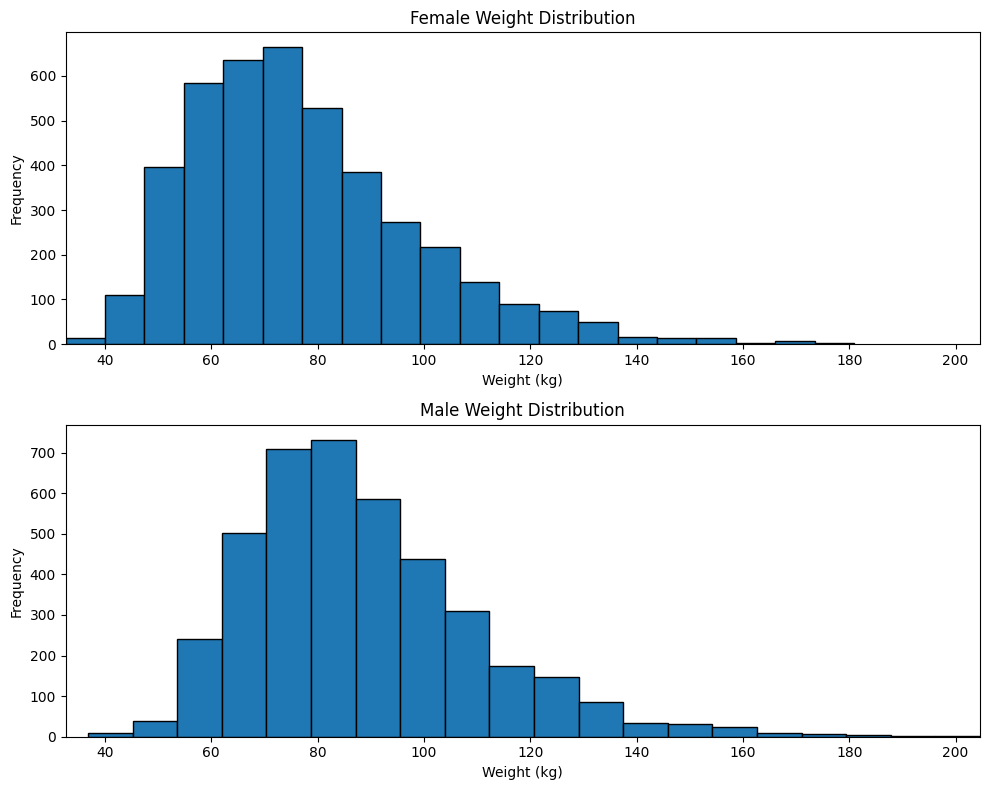

In [ ]:
xmin = np.nanmin(np.concatenate([female_weights, male_weights]))
xmax = np.nanmax(np.concatenate([female_weights, male_weights]))

plt.figure(figsize=(10, 8))

# Female histogram
plt.subplot(2, 1, 1)
plt.hist(female_weights, bins=20, edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Female Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

# Male histogram
plt.subplot(2, 1, 2)
plt.hist(male_weights, bins=20, edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Discussion

The histograms show how body weight is distributed among female and
male participants. Using identical x-axis limits makes it easier to
compare the location, spread, and shape of the two distributions.

## 6. Box-and-Whisker Plot of Weight

A boxplot summarizes the distribution using the median, quartiles,
whiskers, and potential outliers.

/tmp/ipykernel_607/3254714140.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


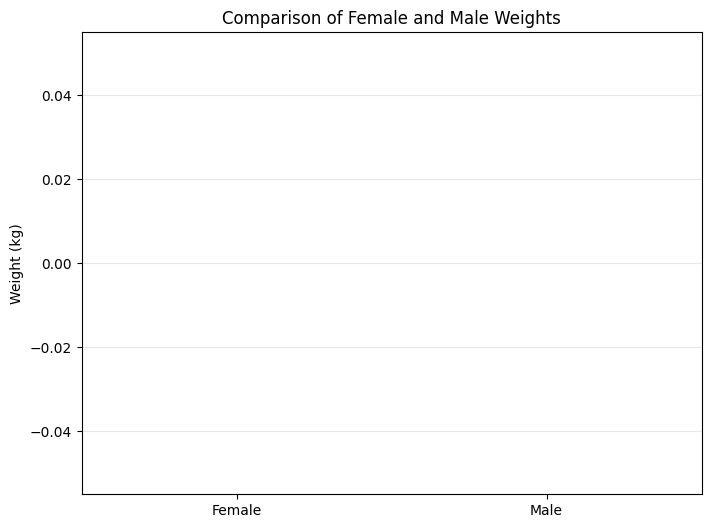

In [ ]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [female_weights, male_weights],
    labels=["Female", "Male"]
)

plt.title("Comparison of Female and Male Weights")
plt.ylabel("Weight (kg)")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Discussion

The boxplot allows the central tendency and dispersion of female and
male weights to be compared. The median is represented by the line
inside each box, while the box represents the interquartile range.
Points beyond the whiskers may represent potential outliers.

## 7. Numerical Statistical Analysis

We calculate:

### Measures of location
- Mean
- Median

### Measures of dispersion
- Minimum
- Maximum
- Range
- Variance
- Standard deviation
- Quartiles

### Measures of shape
- Skewness
- Kurtosis

In [ ]:
def weight_statistics(weights, group_name):

    print("=" * 50)
    print(group_name)
    print("=" * 50)

    print("Mean       :", np.mean(weights))
    print("Median     :", np.median(weights))
    print("Minimum    :", np.min(weights))
    print("Maximum    :", np.max(weights))
    print("Range      :", np.ptp(weights))
    print("Variance   :", np.var(weights))
    print("Std Dev    :", np.std(weights))
    print("Q1         :", np.percentile(weights, 25))
    print("Q3         :", np.percentile(weights, 75))
    print("IQR        :", np.percentile(weights, 75) -
                    np.percentile(weights, 25))
    print("Skewness   :", skew(weights))
    print("Kurtosis   :", kurtosis(weights))


weight_statistics(female_weights, "FEMALE WEIGHT")
weight_statistics(male_weights, "MALE WEIGHT")

FEMALE WEIGHT
Mean       : nan
Median     : nan
Minimum    : nan
Maximum    : nan
Range      : nan
Variance   : nan
Std Dev    : nan
Q1         : nan
Q3         : nan
IQR        : nan
Skewness   : nan
Kurtosis   : nan
MALE WEIGHT
Mean       : nan
Median     : nan
Minimum    : nan
Maximum    : nan
Range      : nan
Variance   : nan
Std Dev    : nan
Q1         : nan
Q3         : nan
IQR        : nan
Skewness   : nan
Kurtosis   : nan


### Discussion

The numerical measures provide a detailed comparison of the two
weight distributions.

- Mean and median describe the central location.
- Standard deviation and IQR describe dispersion.
- Skewness describes asymmetry.
- Kurtosis describes the shape of the distribution relative to a
  normal distribution.

The actual numerical values printed above should be used when writing
the final comparison.

## 8. Calculate BMI for Female Participants

BMI is calculated using weight in kilograms and height in metres.
The original height is stored in centimetres, so it must first be
converted to metres.

In [ ]:
female_height_m = female[:, 1] / 100

female_bmi = female[:, 0] / (female_height_m ** 2)

female = np.column_stack((female, female_bmi))

print("New female matrix shape:", female.shape)
print("\nFirst 5 rows:")
print(female[:5])

New female matrix shape: (4222, 8)

First 5 rows:
[[         nan          nan          nan          nan          nan
           nan          nan          nan]
 [ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849]]


### Result

The female matrix now contains eight columns. The eighth column is BMI.

## 9. Standardize the Female Dataset

Standardization converts each column into z-scores.

Formula:

z = (x - mean) / standard deviation

After standardization, each column has approximately:

- Mean = 0
- Standard deviation = 1

In [ ]:
female_mean = np.mean(female, axis=0)
female_std = np.std(female, axis=0)

zfemale = (female - female_mean) / female_std

print("Shape of zfemale:", zfemale.shape)
print("\nFirst 5 standardized rows:")
print(zfemale[:5])

Shape of zfemale: (4222, 8)

First 5 standardized rows:
[[nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]]


In [ ]:
print("Means of standardized columns:")
print(np.mean(zfemale, axis=0))

print("\nStandard deviations of standardized columns:")
print(np.std(zfemale, axis=0))

Means of standardized columns:
[nan nan nan nan nan nan nan nan]

Standard deviations of standardized columns:
[nan nan nan nan nan nan nan nan]


### Result

The standardized columns have means close to zero and standard
deviations close to one. This makes measurements with different units
and scales easier to compare.

## 10. Scatterplot Matrix

We create a pairplot using the standardized versions of:

- Height
- Weight
- Waist circumference
- Hip circumference
- BMI

The diagonal shows the individual distributions, while the other
panels show pairwise relationships.

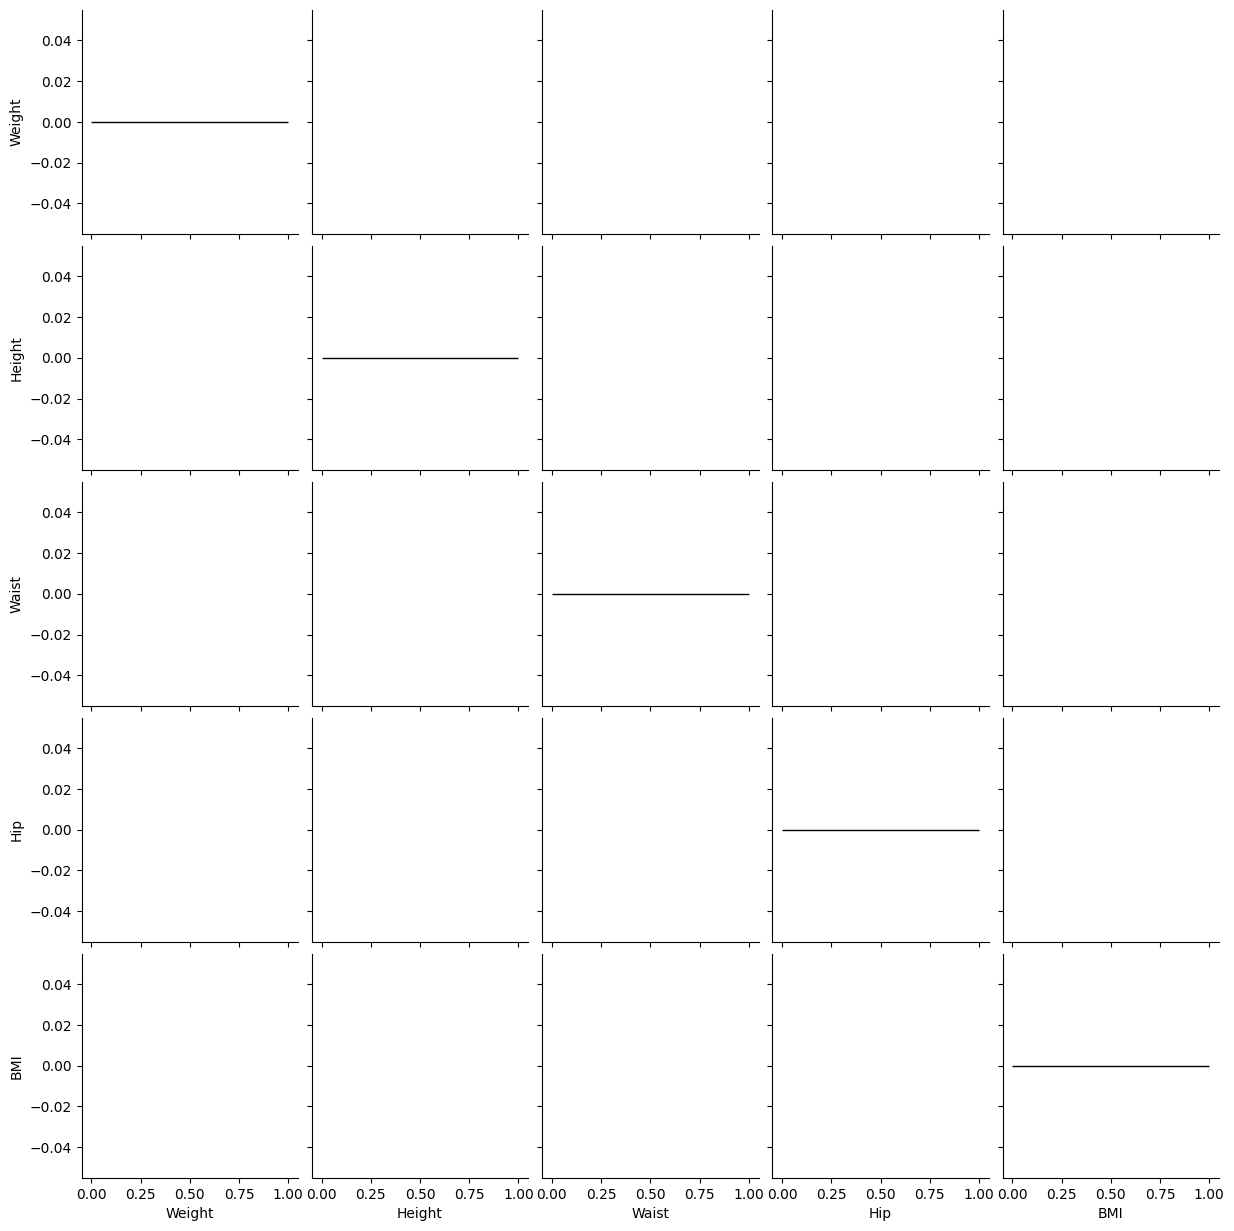

In [ ]:
selected_columns = {
    "Weight": 0,
    "Height": 1,
    "Hip": 5,
    "Waist": 6,
    "BMI": 7
}

zfemale_selected = zfemale[
    :,
    [
        selected_columns["Weight"],
        selected_columns["Height"],
        selected_columns["Waist"],
        selected_columns["Hip"],
        selected_columns["BMI"]
    ]
]

zfemale_df = pd.DataFrame(
    zfemale_selected,
    columns=["Weight", "Height", "Waist", "Hip", "BMI"]
)

sns.pairplot(zfemale_df)
plt.show()

### Discussion

The scatterplot matrix provides a visual overview of relationships
between the selected standardized body measurements.

A rising pattern suggests a positive relationship, while a falling
pattern suggests a negative relationship. A relatively scattered cloud
indicates a weaker linear relationship.

## 11. Pearson Correlation

Pearson correlation measures the strength and direction of a linear
relationship between two variables.

Values range from -1 to +1:

+1  → strong positive linear relationship
 0  → no linear relationship
-1  → strong negative linear relationship

In [ ]:
pearson_matrix = np.corrcoef(zfemale_selected, rowvar=False)

pearson_df = pd.DataFrame(
    pearson_matrix,
    columns=["Weight", "Height", "Waist", "Hip", "BMI"],
    index=["Weight", "Height", "Waist", "Hip", "BMI"]
)

print("Pearson Correlation Matrix:")
display(pearson_df)

Pearson Correlation Matrix:


,Weight,Height,Waist,Hip,BMI
Weight,NaN,NaN,NaN,NaN,NaN
Height,NaN,NaN,NaN,NaN,NaN
Waist,NaN,NaN,NaN,NaN,NaN
Hip,NaN,NaN,NaN,NaN,NaN
BMI,NaN,NaN,NaN,NaN,NaN


## 12. Spearman Correlation

Spearman correlation measures the strength and direction of a
monotonic relationship using the ranks of observations.

In [ ]:
spearman_matrix = np.zeros(
    (zfemale_selected.shape[1], zfemale_selected.shape[1])
)

for i in range(zfemale_selected.shape[1]):
    for j in range(zfemale_selected.shape[1]):
        spearman_matrix[i, j] = spearmanr(
            zfemale_selected[:, i],
            zfemale_selected[:, j]
        ).statistic

spearman_df = pd.DataFrame(
    spearman_matrix,
    columns=["Weight", "Height", "Waist", "Hip", "BMI"],
    index=["Weight", "Height", "Waist", "Hip", "BMI"]
)

print("Spearman Correlation Matrix:")
display(spearman_df)

Spearman Correlation Matrix:


,Weight,Height,Waist,Hip,BMI
Weight,NaN,NaN,NaN,NaN,NaN
Height,NaN,NaN,NaN,NaN,NaN
Waist,NaN,NaN,NaN,NaN,NaN
Hip,NaN,NaN,NaN,NaN,NaN
BMI,NaN,NaN,NaN,NaN,NaN


### Interpretation

Pearson correlation describes linear relationships, whereas Spearman
correlation describes monotonic relationships based on ranks.

When Pearson and Spearman values are similar, the relationship is
generally consistent in both linear and rank-based terms.

The actual correlation matrices printed above should be examined to
identify the strongest positive and negative relationships.

## 13. Calculate Waist-to-Height and Waist-to-Hip Ratios

Two additional body-proportion measurements are calculated:

Waist-to-Height Ratio:

    Waist circumference / Height

Waist-to-Hip Ratio:

    Waist circumference / Hip circumference

In [ ]:
# Female ratios
female_whr = female[:, 6] / female[:, 1]
female_whr = female_whr.reshape(-1, 1)

female_whratio = female[:, 6] / female[:, 5]
female_whratio = female_whratio.reshape(-1, 1)

female = np.column_stack((female, female_whr, female_whratio))


# Male ratios
male_whr = male[:, 6] / male[:, 1]
male_whr = male_whr.reshape(-1, 1)

male_whratio = male[:, 6] / male[:, 5]
male_whratio = male_whratio.reshape(-1, 1)

male = np.column_stack((male, male_whr, male_whratio))


print("Male matrix shape:", male.shape)
print("Female matrix shape:", female.shape)

Male matrix shape: (4082, 9)
Female matrix shape: (4222, 10)


### Result

The female matrix now contains:

7 original measurements + BMI + 2 ratios = 10 columns.

The male matrix contains:

7 original measurements + 2 ratios = 9 columns.

## 14. Comparison of Body Proportion Ratios

The four distributions compared are:

1. Female Waist-to-Height Ratio
2. Male Waist-to-Height Ratio
3. Female Waist-to-Hip Ratio
4. Male Waist-to-Hip Ratio

/tmp/ipykernel_607/103480131.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


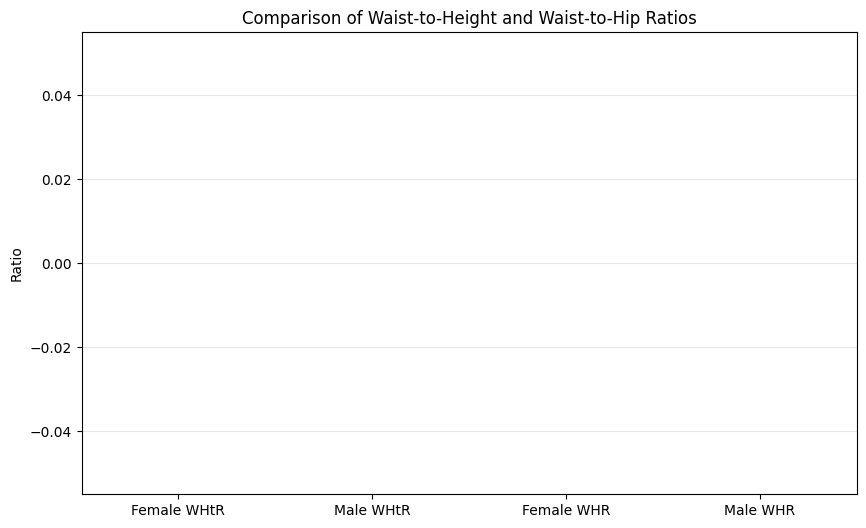

In [ ]:
female_waist_height = female[:, 8]
female_waist_hip = female[:, 9]

male_waist_height = male[:, 7]
male_waist_hip = male[:, 8]

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        female_waist_height,
        male_waist_height,
        female_waist_hip,
        male_waist_hip
    ],
    labels=[
        "Female WHtR",
        "Male WHtR",
        "Female WHR",
        "Male WHR"
    ]
)

plt.title("Comparison of Waist-to-Height and Waist-to-Hip Ratios")
plt.ylabel("Ratio")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Discussion

The boxplot compares body-proportion distributions between males and
females.

The median, interquartile range, whiskers, and possible outliers can
be compared across the four groups. The interpretation should be based
on the positions and spreads visible in the generated plot.

## 15. Advantages and Disadvantages of Body-Composition Measures

### BMI

**Advantages**
- Simple to calculate.
- Uses only height and weight.
- Easy to compare across large populations.
- Useful for broad statistical analysis.

**Disadvantages**
- Does not distinguish muscle from fat.
- Does not show where body fat is distributed.
- Can give the same BMI for people with very different body compositions.

### Waist-to-Height Ratio

**Advantages**
- Includes waist circumference and height.
- Provides information about central body size.
- Easy to calculate.

**Disadvantages**
- Requires an accurate waist measurement.
- Does not directly measure body-fat percentage.
- Results can be affected by measurement technique.

### Waist-to-Hip Ratio

**Advantages**
- Considers both waist and hip circumference.
- Describes body-fat distribution/proportions.
- Useful for comparing body shape.

**Disadvantages**
- Requires two circumference measurements.
- Sensitive to measurement technique.
- Does not directly measure total body fat.

## 16. Participants with the Lowest and Highest BMI

We sort the BMI column and select:

- 5 participants with the lowest BMI
- 5 participants with the highest BMI

Their standardized body measurements are then displayed.

In [ ]:
# BMI is column 7 in the female matrix
bmi = female[:, 7]

# Sort BMI indices
sorted_indices = np.argsort(bmi)

# Five lowest BMI
lowest_bmi_indices = sorted_indices[:5]

# Five highest BMI
highest_bmi_indices = sorted_indices[-5:][::-1]

print("Indices of 5 lowest BMI participants:")
print(lowest_bmi_indices)

print("\nIndices of 5 highest BMI participants:")
print(highest_bmi_indices)

Indices of 5 lowest BMI participants:
[ 263 3479 2127 2754 1210]

Indices of 5 highest BMI participants:
[   0 1097 1105 1473 3023]


In [ ]:
extreme_indices = np.concatenate(
    [lowest_bmi_indices, highest_bmi_indices]
)

print("Standardized measurements of 5 lowest and 5 highest BMI participants:")
print()

print(zfemale[extreme_indices])

Standardized measurements of 5 lowest and 5 highest BMI participants:

[[nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan]]


In [ ]:
zfemale_df = pd.DataFrame(
    zfemale,
    columns=[
        "Weight",
        "Height",
        "UpperArmLength",
        "UpperLegLength",
        "ArmCircumference",
        "Hip",
        "Waist",
        "BMI"
    ]
)

print("5 LOWEST BMI PARTICIPANTS")
display(zfemale_df.iloc[lowest_bmi_indices])

print("\n5 HIGHEST BMI PARTICIPANTS")
display(zfemale_df.iloc[highest_bmi_indices])

5 LOWEST BMI PARTICIPANTS


,Weight,Height,UpperArmLength,UpperLegLength,ArmCircumference,Hip,Waist,BMI
263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



5 HIGHEST BMI PARTICIPANTS


,Weight,Height,UpperArmLength,UpperLegLength,ArmCircumference,Hip,Waist,BMI
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1105,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 17. Interpretation of Extreme BMI Participants

The standardized values show how the selected participants differ from
the average female participant.

A positive z-score means that the measurement is above the female
dataset average, while a negative z-score means that it is below the
average.

The five lowest-BMI participants generally represent observations with
relatively lower BMI values, while the five highest-BMI participants
represent observations with relatively higher BMI values.

The standardized measurements can be used to examine whether the
extreme BMI values are accompanied by unusually high or low values of
weight, height, waist circumference, hip circumference, or other body
measurements.

# 18. Project Summary

This project analyzed NHANES body measurements for adult males and
females using NumPy and Python.

The following tasks were completed:

1. Loaded the NHANES male and female datasets.
2. Stored the datasets as NumPy matrices.
3. Compared male and female weight distributions using histograms.
4. Compared weights using box-and-whisker plots.
5. Calculated numerical statistical aggregates.
6. Added BMI to the female matrix.
7. Standardized the female matrix using z-scores.
8. Created a scatterplot matrix for selected standardized variables.
9. Calculated Pearson and Spearman correlation coefficients.
10. Added waist-to-height and waist-to-hip ratios.
11. Compared the four ratio distributions using a boxplot.
12. Discussed advantages and disadvantages of BMI and body-proportion
    measures.
13. Identified the five lowest and five highest BMI participants and
    examined their standardized measurements.

## Conclusion

The analysis demonstrates how NumPy matrices, statistical measures,
visualization, standardization, and correlation analysis can be used
to explore multidimensional body-measurement data.

In [ ]:
# ============================
# FEMALE RATIOS
# ============================

female_waist_height_ratio = female[:, 6] / female[:, 1]
female_waist_hip_ratio = female[:, 6] / female[:, 5]

female = np.column_stack(
    (
        female,
        female_waist_height_ratio,
        female_waist_hip_ratio
    )
)


# ============================
# MALE RATIOS
# ============================

male_waist_height_ratio = male[:, 6] / male[:, 1]
male_waist_hip_ratio = male[:, 6] / male[:, 5]

male = np.column_stack(
    (
        male,
        male_waist_height_ratio,
        male_waist_hip_ratio
    )
)

print("Male matrix shape:", male.shape)
print("Female matrix shape:", female.shape)

Male matrix shape: (4082, 11)
Female matrix shape: (4222, 12)


In [ ]:
female_waist_height = female[:, 8]
female_waist_hip = female[:, 9]

male_waist_height = male[:, 7]
male_waist_hip = male[:, 8]